# Module 07b — Static Backtest with Pair Loss-Streak Timeout

Post-hoc risk-control extension of the original static Module 07. The original 40-pair formation universe and all original model rules remain frozen. The only added rule is: after **3 consecutive losing closed trades** for a pair, block new entries in that pair for **6 calendar months**. A winning trade resets the loss streak; triggering a timeout starts a new streak cycle after the cooldown. Existing open positions are never force-closed by the timeout.

This notebook should be reported as a diagnostic/risk-control extension, not as the original untouched out-of-sample specification.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from src.backtest import backtest_summary
from src.backtest_pair_timeout import run_walk_forward_backtest_with_pair_timeout
pd.set_option('display.max_columns', 120)
OUT = Path('data/processed/pair_timeout')
OUT.mkdir(parents=True, exist_ok=True)

## 1. Load the same frozen inputs as Module 07

In [2]:
train_prices = pd.read_parquet('data/processed/train_prices.parquet').sort_index()
test_prices = pd.read_parquet('data/processed/test_prices.parquet').sort_index()
eligible_pairs = pd.read_parquet('data/processed/eligible_pairs.parquet')
cointegrated_pairs = pd.read_parquet('data/processed/cointegrated_pairs.parquet')
rf_data = pd.read_parquet('data/processed/risk_free_rates.parquet')
risk_free_rates = rf_data.iloc[:,0] if isinstance(rf_data, pd.DataFrame) else pd.Series(rf_data)
risk_free_rates.index = pd.to_datetime(risk_free_rates.index)
risk_free_rates = risk_free_rates.sort_index().astype(float)
assert isinstance(train_prices.index, pd.DatetimeIndex)
assert isinstance(test_prices.index, pd.DatetimeIndex)
assert train_prices.index.max() < test_prices.index.min()
print('Train:', train_prices.index.min(), '->', train_prices.index.max(), train_prices.shape)
print('Test :', test_prices.index.min(), '->', test_prices.index.max(), test_prices.shape)
print('Eligible pairs:', len(eligible_pairs))

Train: 2016-01-04 00:00:00 -> 2022-12-27 00:00:00 (1759, 466)
Test : 2022-12-28 00:00:00 -> 2025-12-31 00:00:00 (755, 466)
Eligible pairs: 40


## 2. Fixed strategy and timeout specification

In [8]:
INITIAL_CAPITAL = 100_000.0
ENTRY_Z = 1.5
TARGET_PROBABILITY = 0.70
MEMORY_WINDOW = 60
MAX_HORIZON_DAYS = 126
N_PATHS = 5000
EWMA_LAMBDA = 0.94
SEED = 42
LOSS_STREAK_TRIGGER = 2
TIMEOUT_MONTHS = 6
print(f'Timeout rule: {LOSS_STREAK_TRIGGER} consecutive losing trades -> {TIMEOUT_MONTHS} calendar months blocked')

Timeout rule: 2 consecutive losing trades -> 6 calendar months blocked


## 3. Run static OOS backtest with pair timeout

In [9]:
results = run_walk_forward_backtest_with_pair_timeout(
    train_prices=train_prices,
    test_prices=test_prices,
    eligible_pairs=eligible_pairs,
    cointegrated_pairs=cointegrated_pairs,
    risk_free_rates=risk_free_rates,
    initial_capital=INITIAL_CAPITAL,
    entry_z=ENTRY_Z,
    target_probability=TARGET_PROBABILITY,
    memory_window=MEMORY_WINDOW,
    max_horizon_days=MAX_HORIZON_DAYS,
    n_paths=N_PATHS,
    ewma_lambda=EWMA_LAMBDA,
    seed=SEED,
    loss_streak_trigger=LOSS_STREAK_TRIGGER,
    timeout_months=TIMEOUT_MONTHS,
)
trades = results['trades']
equity_curve = results['equity_curve']
skipped_signals = results['skipped_signals']
timeout_events = results['timeout_events']
print('Completed trades:', len(trades))
print('Timeout events  :', len(timeout_events))
print('Final equity    :', equity_curve['equity'].iloc[-1])

Completed trades: 224
Timeout events  : 32
Final equity    : 137381.18547494398


## 4. Headline performance

In [10]:
summary = backtest_summary(trades, equity_curve, INITIAL_CAPITAL)
display(summary.to_frame('value'))
display(timeout_events)
if len(skipped_signals):
    display(skipped_signals.groupby('reason').size().sort_values(ascending=False).rename('count').to_frame())

,value
initial_capital,100000.000000
final_equity,137381.185475
total_return,0.373812
max_drawdown,-0.478324
n_trades,224.000000
win_rate,0.495536
average_trade_return,0.098378
median_trade_return,-0.020025
max_concurrent_positions,28.000000


,pair,trigger_date,timeout_until,loss_streak_trigger,timeout_months
0,URI-MS,2023-06-22,2023-12-22,2,6
1,ETN-KLAC,2023-09-25,2024-03-25,2,6
2,LYV-AXP,2023-10-02,2024-04-02,2,6
3,MAS-LEN,2023-10-16,2024-04-16,2,6
4,SHW-DHI,2023-10-17,2024-04-17,2,6
5,IFF-SWK,2023-11-20,2024-05-20,2,6
6,BKNG-MAR,2023-12-08,2024-06-08,2,6
7,MKC-CHD,2024-02-26,2024-08-26,2,6
8,PEP-HSY,2024-04-04,2024-10-04,2,6
9,SHW-MSCI,2024-04-08,2024-10-08,2,6


,count
reason,
pair_timeout,3786
insufficient_cash,580


## 5. Equity curve and timeout timing

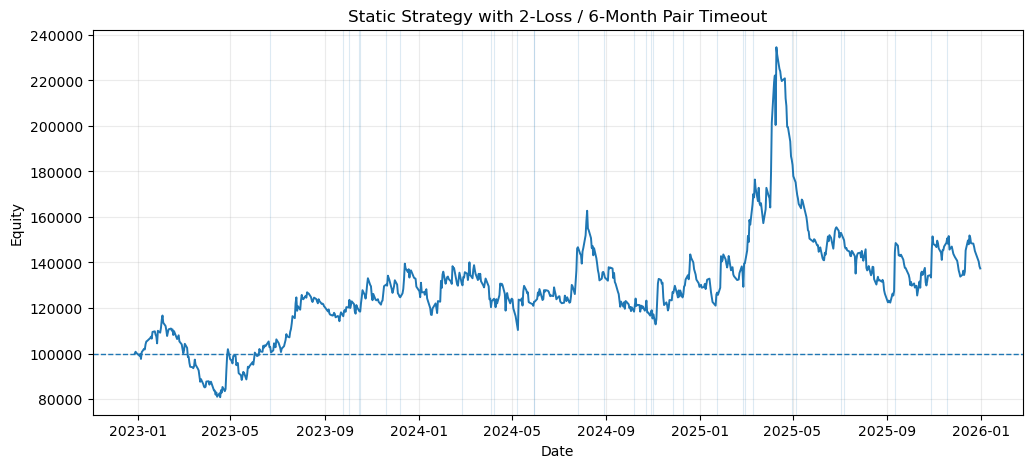

In [11]:
plt.figure(figsize=(12,5))
plt.plot(equity_curve.index, equity_curve['equity'], linewidth=1.4)
plt.axhline(INITIAL_CAPITAL, linestyle='--', linewidth=1)
for d in pd.to_datetime(timeout_events.get('trigger_date', pd.Series(dtype='datetime64[ns]'))):
    plt.axvline(d, alpha=0.15, linewidth=0.8)
plt.title('Static Strategy with 2-Loss / 6-Month Pair Timeout')
plt.xlabel('Date'); plt.ylabel('Equity'); plt.grid(alpha=.25); plt.show()

## 6. Save extension results

In [12]:
trades.to_parquet(OUT/'trades.parquet', index=False)
equity_curve.to_parquet(OUT/'equity_curve.parquet')
skipped_signals.to_parquet(OUT/'skipped_signals.parquet', index=False)
timeout_events.to_parquet(OUT/'timeout_events.parquet', index=False)
summary.to_frame('value').to_csv(OUT/'summary.csv')
print('Saved to', OUT)

Saved to data\processed\pair_timeout


## Interpretation guardrail

Compare this extension against the original Module 07, but do not describe an improvement as fresh out-of-sample evidence. The timeout rule was introduced after observing losses in the original OOS backtest. Its value is therefore diagnostic: it tests whether repeated pair-level losses were concentrated enough that a simple stateful risk-control rule would have reduced tail damage.